# **Perspective Transforms**

### **Objectives:**

1. Using OpenCV's getPerspectiveTransform
2. Using findContours to get corners and automate perspective Transform


> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

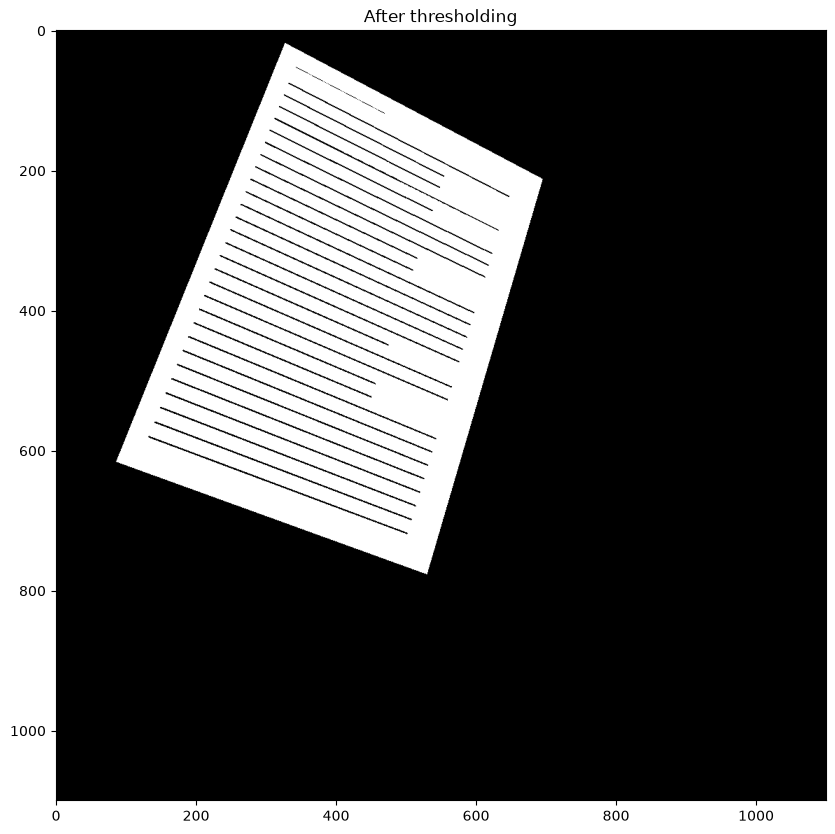

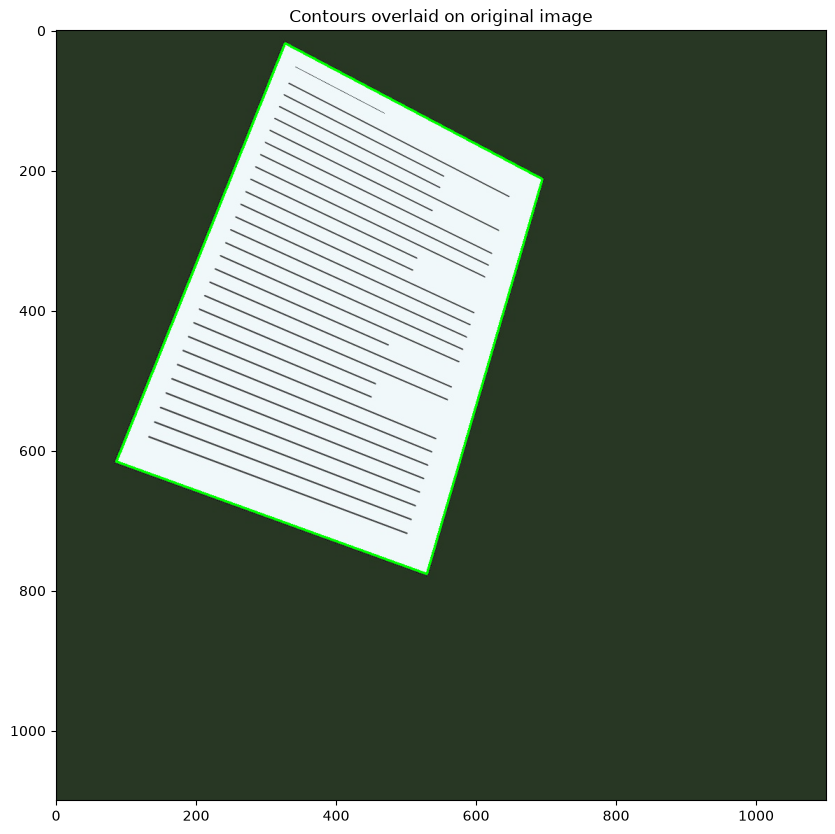

Number of Contours found = 1


In [2]:
image = cv2.imread('./assets/images/scan.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))

### **Approxiamte our contour above to just 4 points using approxPolyDP**

In [3]:
# Sort contours large to small by area

sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# loop over the contours
for cnt in sorted_contours:
	# approximate the contour
	perimeter = cv2.arcLength(cnt, True)
	approx = cv2.approxPolyDP(cnt, 0.05 * perimeter, True)
 
	if len(approx) == 4:
		break

# Our x, y cordinates of the four corners 
print("Our 4 corner points are:")
print(approx)

Our 4 corner points are:
[[[327  18]]

 [[ 86 615]]

 [[530 776]]

 [[695 212]]]


### **Use getPerspectiveTransform and warpPerspective to create our top down view**

Note: We mannauly matched the order of the points

**Why this needs a *perspective* transform, not the affine one from notebook 05:** an affine transform (2×3 matrix) can rotate, scale, translate, and shear, but it always keeps parallel lines parallel — it physically cannot represent "this page was photographed at an angle, so its far edge looks shorter." A homography (the 3×3 matrix `getPerspectiveTransform` returns) adds one more degree of freedom: the bottom row isn't forced to be `[0, 0, 1]` anymore, which lets it *converge* lines the way a real camera does. Concretely, mapping a point now involves a division:

$$x' = \frac{ax + by + c}{gx + hy + 1}, \quad y' = \frac{dx + ey + f}{gx + hy + 1}$$

That denominator is the whole trick — it's what lets far-apart pixels in the skewed original get squeezed closer together (or stretched apart) in the output, undoing exactly the distortion a camera's perspective introduced. With 4 point correspondences (the 4 document corners found above) and 8 unknowns (a,b,c,d,e,f,g,h — the matrix is defined only up to scale, so 9 entries minus 1 constraint), the system is fully determined — which is exactly why the corner-finding step needed *exactly* 4 points, no more, no fewer.

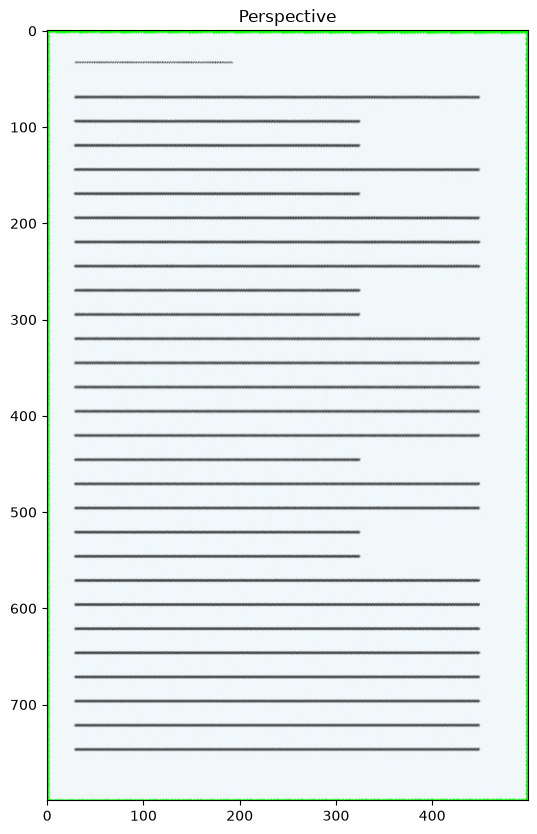

In [4]:
# Order obtained here is top left, bottom left, bottom right, top right
inputPts = np.float32(approx)

outputPts = np.float32([[0,0],
                       [0,800],
                       [500,800],
                       [500,0]])

# Get our Transform Matrix, M
M = cv2.getPerspectiveTransform(inputPts,outputPts)

# Apply the transform Matrix M using Warp Perspective
dst = cv2.warpPerspective(image, M, (500,800))

imshow("Perspective", dst)

### If you're curious to dig deeper

- Automate corner ordering: `approx` isn't guaranteed to come out top-left→bottom-left→bottom-right→top-right — write an `order_points()` helper using sum/diff of coordinates instead of hardcoding the order.
- OCR the flattened output with `pytesseract.image_to_string(dst)` if you have Tesseract installed — perspective correction is exactly the preprocessing step real document scanners do before OCR.